In [18]:
#Question 1, Task 1

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv("01_mlb-team-seasons.csv")

df["log_odds_WP"] = np.log(df["WP"] / (1 - df["WP"]))
df["log_RS_RA"] = np.log(df["RS"] / df["RA"])

X = df["log_RS_RA"].values.reshape(-1, 1)
y = df["log_odds_WP"].values

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

coef = model.coef_[0]
r2 = model.score(X, y)

print(f"Coefficient (slope): {coef:.6f}")
print(f"R²: {r2:.6f}")
print(f"\nModel: log(WP / (1 - WP)) = {coef:.6f} * log(RS / RA)")

Coefficient (slope): 1.799718
R²: 0.897339

Model: log(WP / (1 - WP)) = 1.799718 * log(RS / RA)


Fitted α=1.7997:  RMSE = 0.027792  |  R² = 0.898727
α=2:  RMSE = 0.027801  |  R² = 0.898666


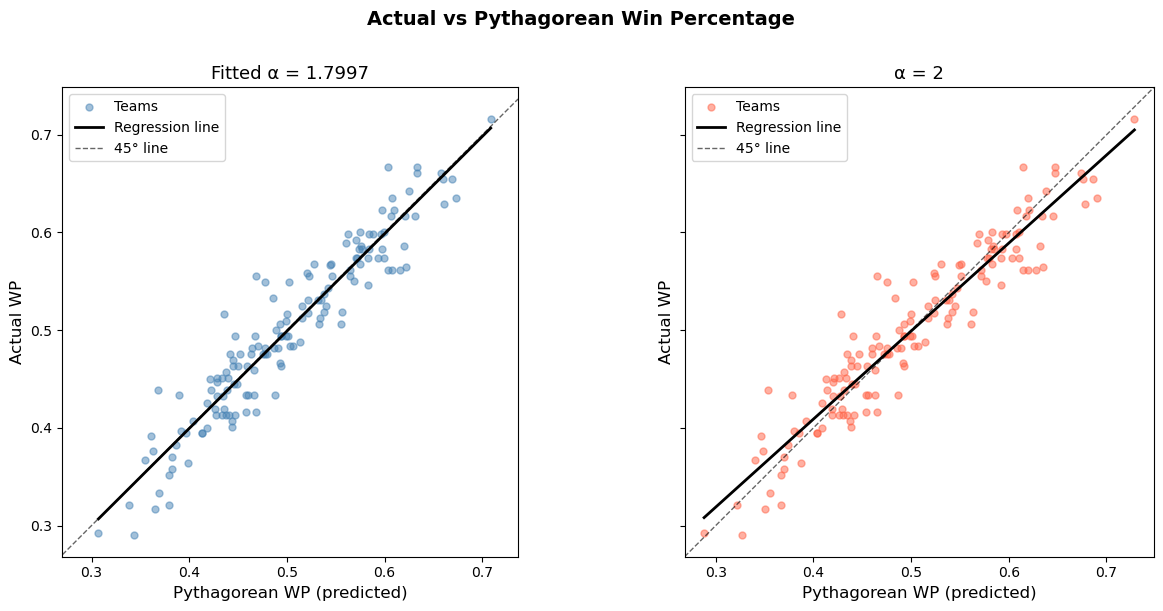

In [19]:
#Question 1, Task 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df["pythag_fitted"] = df["RS"] ** coef / (df["RS"] ** coef + df["RA"] ** coef)
df["pythag_alpha2"] = df["RS"] ** 2   / (df["RS"] ** 2   + df["RA"] ** 2)

y = df["WP"].values

# --- RMSE comparison ---
for key, label in [("pythag_fitted", f"Fitted α={coef:.4f}"), ("pythag_alpha2", "α=2")]:
    X = df[key].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    rmse = np.sqrt(mean_squared_error(y, model.predict(X)))
    print(f"{label}:  RMSE = {rmse:.6f}  |  R² = {model.score(X, y):.6f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
configs = [
    ("pythag_fitted", f"Fitted α = {coef:.4f}", "steelblue"),
    ("pythag_alpha2", "α = 2",                  "tomato"),
]

for ax, (key, title, color) in zip(axes, configs):
    X_pythag = df[key].values
    model = LinearRegression()
    model.fit(X_pythag.reshape(-1, 1), y)
    x_line = np.linspace(X_pythag.min(), X_pythag.max(), 200)
    y_line = model.predict(x_line.reshape(-1, 1))

    lims = [min(X_pythag.min(), y.min()) - 0.02, max(X_pythag.max(), y.max()) + 0.02]

    ax.scatter(X_pythag, y, alpha=0.5, s=25, color=color, label="Teams")
    ax.plot(x_line, y_line, color="black",  linewidth=2,   label="Regression line")
    ax.plot(lims,   lims,   "k--",          linewidth=1,   alpha=0.6, label="45° line")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel("Pythagorean WP (predicted)", fontsize=12)
    ax.set_ylabel("Actual WP", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)

plt.suptitle("Actual vs Pythagorean Win Percentage", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("pythag_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
#Q1, Task 3

import statsmodels.api as sm


X = df["log_RS_RA"].values
y = df["log_odds_WP"].values

model = sm.OLS(y, X).fit()  # no intercept — don't wrap X in sm.add_constant()
print(model.summary())

coef = model.params[0]
se   = model.bse[0]
ci   = model.conf_int(alpha=0.05)

print(f"Standard Error:    {se:.6f}")
print(f"95% CI:            ({ci[0][0]:.6f}, {ci[0][1]:.6f})")


#Alpha = 2 is not within the 95% confidence interval, so it's not plausible.

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.897
Model:                            OLS   Adj. R-squared (uncentered):              0.897
Method:                 Least Squares   F-statistic:                              1302.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):                    1.54e-75
Time:                        14:29:19   Log-Likelihood:                          111.59
No. Observations:                 150   AIC:                                     -221.2
Df Residuals:                     149   BIC:                                     -218.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

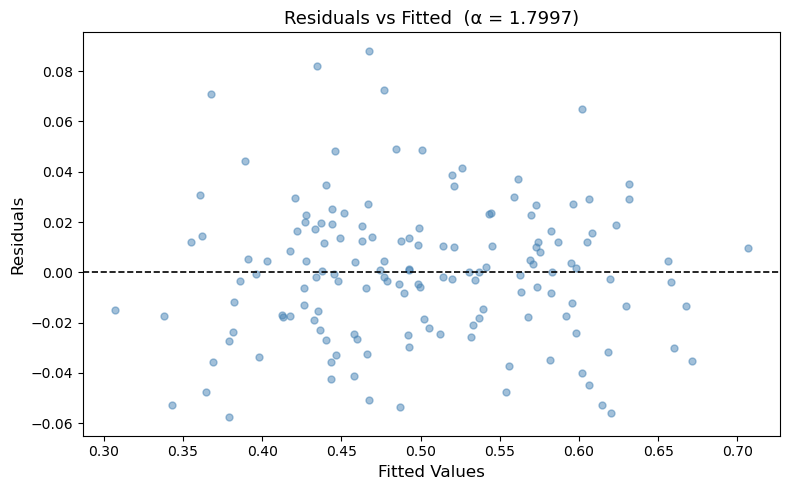

In [24]:
#Q1, task 4

X = df["pythag_fitted"].values.reshape(-1, 1)
y = df["WP"].values
model = LinearRegression()
model.fit(X, y)

fitted    = model.predict(X)
residuals = y - fitted

# Residual diagnostic plot
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.5, s=25, color="steelblue")
plt.axhline(0, color="black", linewidth=1.2, linestyle="--")
plt.xlabel("Fitted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title(f"Residuals vs Fitted  (α = {coef:.4f})", fontsize=13)
plt.tight_layout()
plt.show()

#If the model is reasonable, I would expect to see heteroscedasticity (i.e. the residuals should not grow larger/smaller on average as the fitted values increase.)
#I would also hope that the expectation of residuals is 0. 

##I don't see changing spread,curvature or spread.

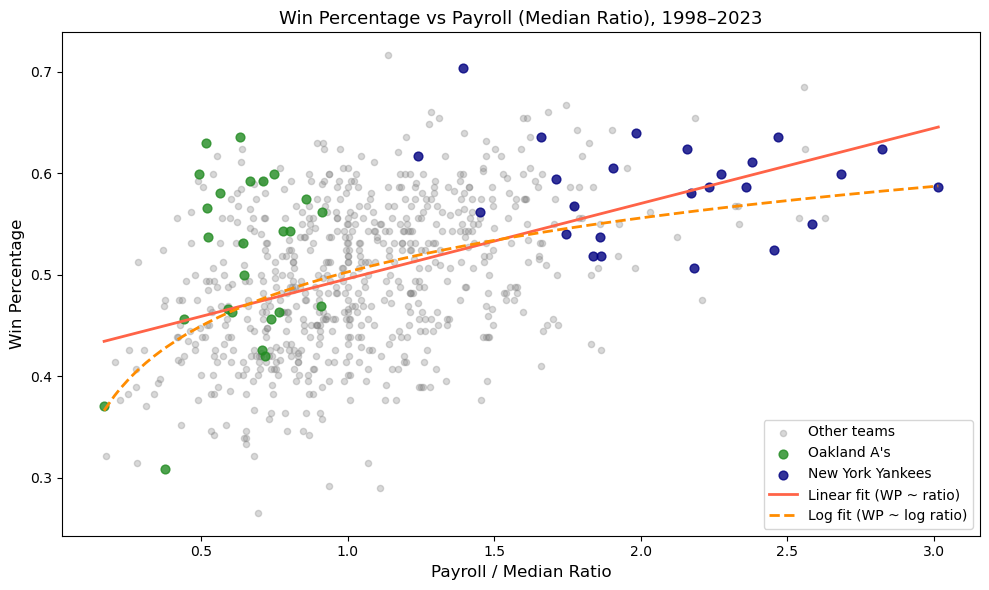

In [26]:
#Question 2 task 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("01_mlb-payrolls.csv")

# (1) Remove 2020
df = df[df["year_id"] != 2020].copy()

# Team masks
oak   = df["team_id"] == "OAK"
nyy   = df["team_id"] == "NYA"
other = ~oak & ~nyy

X_ratio = df["payroll_median_ratio"].values
X_log   = df["log_payroll_median_ratio"].values
y       = df["wp"].values

# Regression: WP ~ payroll_median_ratio
m_linear = LinearRegression()
m_linear.fit(X_ratio.reshape(-1, 1), y)

# Regression: WP ~ log_payroll_median_ratio
m_log = LinearRegression()
m_log.fit(X_log.reshape(-1, 1), y)

# Lines sorted by payroll_median_ratio for clean plotting
sort_idx  = np.argsort(X_ratio)
x_ratio_s = X_ratio[sort_idx]
x_log_s   = X_log[sort_idx]
y_linear  = m_linear.predict(x_ratio_s.reshape(-1, 1))
y_log     = m_log.predict(x_log_s.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df.loc[other, "payroll_median_ratio"], df.loc[other, "wp"],
           alpha=0.3, s=20, color="gray", label="Other teams")
ax.scatter(df.loc[oak, "payroll_median_ratio"], df.loc[oak, "wp"],
           alpha=0.8, s=40, color="forestgreen", label="Oakland A's")
ax.scatter(df.loc[nyy, "payroll_median_ratio"], df.loc[nyy, "wp"],
           alpha=0.8, s=40, color="navy", label="New York Yankees")

ax.plot(x_ratio_s, y_linear, color="tomato",     linewidth=2,              label="Linear fit (WP ~ ratio)")
ax.plot(x_ratio_s, y_log,    color="darkorange",  linewidth=2, linestyle="--", label="Log fit (WP ~ log ratio)")

ax.set_xlabel("Payroll / Median Ratio", fontsize=12)
ax.set_ylabel("Win Percentage", fontsize=12)
ax.set_title("Win Percentage vs Payroll (Median Ratio), 1998–2023", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

  team_id  year_id    g    w    l  win_per        wp  wins_162  attendance  \
0     ARI     1998  162   65   97     40.1  0.401235      65.0   3610290.0   
1     ARI     1999  162  100   62     61.7  0.617284     100.0   3019654.0   
2     ARI     2000  162   85   77     52.5  0.524691      85.0   2942251.0   
3     ARI     2001  162   92   70     56.8  0.567901      92.0   2736451.0   
4     ARI     2002  162   98   64     60.5  0.604938      98.0   3198977.0   
5     ARI     2003  162   84   78     51.9  0.518519      84.0   2805542.0   
6     ARI     2004  162   51  111     31.5  0.314815      51.0   2519560.0   
7     ARI     2005  162   77   85     47.5  0.475309      77.0   2059424.0   
8     ARI     2006  162   76   86     46.9  0.469136      76.0   2091685.0   
9     ARI     2007  162   90   72     55.6  0.555556      90.0   2325249.0   

                   name  opening_day_26_man  year_end_40_man  source  \
0  Arizona Diamondbacks            29161500              NaN  BBCube 

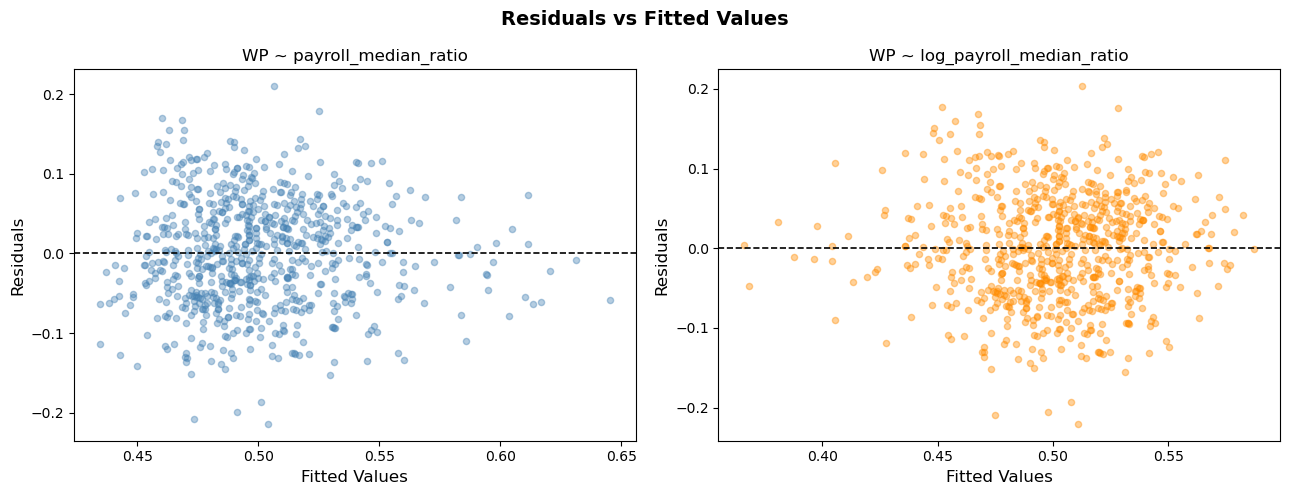

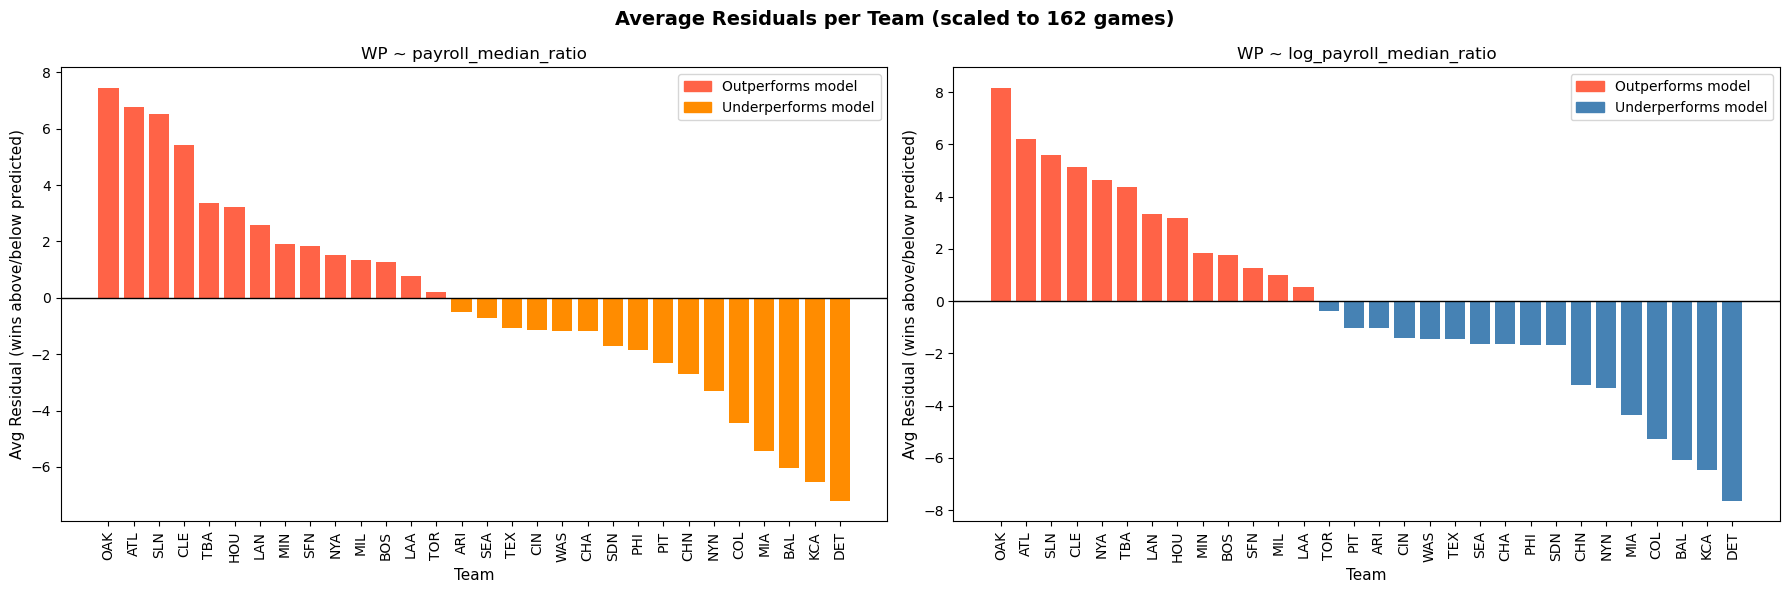

In [39]:
#Q2, task 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


X_ratio = df["payroll_median_ratio"].values.reshape(-1, 1)
X_log   = df["log_payroll_median_ratio"].values.reshape(-1, 1)
y       = df["wp"].values

m_linear = LinearRegression()
m_linear.fit(X_ratio, y)

m_log = LinearRegression()
m_log.fit(X_log, y)

fitted_linear = m_linear.predict(X_ratio)
fitted_log    = m_log.predict(X_log)

# (A) and (B): residual columns
df["resid_linear"] = y - fitted_linear
df["resid_log"]    = y - fitted_log

print(df.head(10))   #Demonstrating that columns have been added

# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, fitted, resid_col, title, color in [
    (axes[0], fitted_linear, "resid_linear", "WP ~ payroll_median_ratio",     "steelblue"),
    (axes[1], fitted_log,    "resid_log",    "WP ~ log_payroll_median_ratio",  "darkorange"),
]:
    ax.scatter(fitted, df[resid_col], alpha=0.4, s=20, color=color)
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Fitted Values", fontsize=12)
    ax.set_ylabel("Residuals", fontsize=12)
    ax.set_title(title, fontsize=12)

plt.suptitle("Residuals vs Fitted Values", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##Discussion of residual distribution
#Explanation: In the case where we regress against the payroll ratio, the residuals grow smaller as fitted values increase, violating heteroscedasticity.
#             This is not the case with the residuals from using the log of the payroll ratio.




#Displaying residual plots for each team.
avg_linear = (df.groupby("team_id")["resid_linear"].mean() * 162).sort_values(ascending=False)
avg_log    = (df.groupby("team_id")["resid_log"].mean()    * 162).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, avg, title, color in [
    (axes[0], avg_linear, "WP ~ payroll_median_ratio",     "steelblue"),
    (axes[1], avg_log,    "WP ~ log_payroll_median_ratio",  "darkorange"),
]:
    bars = ax.bar(avg.index, avg.values, color=[
        "tomato" if v >= 0 else "steelblue" if color == "darkorange" else "darkorange"
        for v in avg.values
    ])
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("Team", fontsize=11)
    ax.set_ylabel("Avg Residual (wins above/below predicted)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="x", rotation=90)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="tomato",                                          label="Outperforms model"),
        Patch(color="steelblue" if color == "darkorange" else "darkorange", label="Underperforms model"),
    ], fontsize=10)

plt.suptitle("Average Residuals per Team (scaled to 162 games)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [57]:
#Task 2, Q3

#2008 Oakland As

import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("01_mlb-payrolls.csv")
df = df[df["year_id"] != 2020].copy()

X = sm.add_constant(df["log_payroll_median_ratio"].values)
y = df["wp"].values

model = sm.OLS(y, X).fit()

# Isolate 2008 Oakland A's
oak_2008 = df[(df["team_id"] == "OAK") & (df["year_id"] == 2008)]
log_val  = oak_2008["log_payroll_median_ratio"].values[0]
actual   = oak_2008["wp"].values[0]
print(f"2008 OAK  |  log_payroll_median_ratio: {log_val:.6f}  |  Actual WP: {actual:.6f}")

# Pass as a 2D array with explicit constant
x_pred  = np.array([[1.0, log_val]])

pred    = model.get_prediction(x_pred)
summary = pred.summary_frame(alpha=0.05)

print(f"\nPredicted WP:                    {summary['mean'].values[0]:.6f}")
print(f"95% Confidence Interval (mean):  ({summary['mean_ci_lower'].values[0]:.6f}, {summary['mean_ci_upper'].values[0]:.6f})")
print(f"95% Prediction Interval (indiv): ({summary['obs_ci_lower'].values[0]:.6f}, {summary['obs_ci_upper'].values[0]:.6f})")


#The prediction interval should be wider than the confidence interval, because the former needs to account for uncertainty from model errors, whereas the latter does not account for that factor.

2008 OAK  |  log_payroll_median_ratio: -0.523161  |  Actual WP: 0.465839

Predicted WP:                    0.462571
95% Confidence Interval (mean):  (0.455012, 0.470130)
95% Prediction Interval (indiv): (0.329617, 0.595525)
